# Linear Regression -Healthcare Cost Prediction



Objective:
Build a fully validated Linear Regression model to predict annual medical costs using demographic, medical, and insurance data. The project includes preprocessing, exploratory analysis, model diagnostics, and performance evaluation.

In [73]:
import pandas as pd
import numpy as np

## Dataset Selection

A healthcare insurance dataset containing 100,000 observations was selected for this analysis. The dataset includes demographic, lifestyle, medical history, and insurance-related variables for policyholders.



In [74]:
df=pd.read_csv("/content/medical_insurance.csv")

## Data Understanding and Problem Framing

### Real-world context
Health insurance companies must estimate expected healthcare expenses for policyholders in order to price insurance plans, manage risk, and allocate healthcare resources.

### Prediction Goal
Predict the **annual medical cost incurred by each individual**.

### Why This Matters
Healthcare cost prediction helps insurance companies:
- set appropriate premiums
- identify high-risk patients
- manage healthcare expenditures
- design preventive healthcare programs

### Stakeholders
- Insurance companies
- Healthcare providers
- Government healthcare planners

In [36]:
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

The dataset contains:
- 100,000 rows
- 54 columns

Feature types include:
- numerical variables
- categorical variables
- ordinal variables
- binary medical condition indicators

In [38]:
df.describe

<bound method NDFrame.describe of        person_id  age     sex   region urban_rural    income     education  \
0          75722   52  Female    North    Suburban   22700.0     Doctorate   
1          80185   79  Female    North       Urban   12800.0         No HS   
2          19865   68    Male    North       Rural   40700.0            HS   
3          76700   15    Male    North    Suburban   15600.0  Some College   
4          92992   53    Male  Central    Suburban   89600.0     Doctorate   
...          ...  ...     ...      ...         ...       ...           ...   
99995       6266   50    Male     West       Urban  127200.0         No HS   
99996      54887   42    Male     East    Suburban   21600.0            HS   
99997      76821   41    Male     West       Rural   81900.0            HS   
99998        861   51  Female    South       Urban   43400.0     Doctorate   
99999      15796   44  Female    South       Rural   43700.0  Some College   

      marital_status employment_status  household_size  ...  liver_disease  \
0            Married           Retired               3  ...              0   
1            Married          Employed               3  ...              0   
2            Married           Retired               5  ...              0   
3            Married     Self-employed               5  ...              0   
4            Married     Self-employed               2  ...              0   
...              ...               ...             ...  ...            ...   
99995        Married          Employed               2  ...              0   
99996        Married          Employed               2  ...              0   
99997       Divorced        Unemployed               1  ...              0   
99998         Single        Unemployed               3  ...              0   
99999        Married          Employed               2  ...              0   

       arthritis mental_health proc_imaging_count  proc_surgery_count  \
0              1             0                  1                   0   
1              1             1                  0                   0   
2              0             1                  1                   0   
3              0             0                  1                   0   
4              1             0                  2                   0   
...          ...           ...                ...                 ...   
99995          0             0                  0                   0   
99996          0             0                  0                   0   
99997          0             0                  1                   0   
99998          0             1                  0                   0   
99999          0             0                  0                   0   

       proc_physio_count  proc_consult_count  proc_lab_count  is_high_risk  \
0                      2                   0               1             0   
1                      1                   0               1             1   
2                      2                   1               0             1   
3                      0                   1               0             0   
4                      1                   1               0             1   
...                  ...                 ...             ...           ...   
99995                  1                   0               0             0   
99996                  0                   0               0             0   
99997                  1                   0               0             0   
99998                  2                   2               1             0   
99999                  1                   1               1             0   

       had_major_procedure  
0                        0  
1                        0  
2                        0  
3                        0  
4                        0  
...                    ...  
99995                    0  
99996                    0  
99997            

In [39]:
df.head(5)

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


# Feature Type Classification
### Numerical Variables
age, bmi, income, systolic_bp, diastolic_bp, etc.

### Categorical Variables
sex, region, marital_status, employment_status, plan_type

### Ordinal Variables
education, network_tier

### Binary Variables
hypertension, diabetes, asthma, etc.

### Initial Data Quality Issues

Several data quality considerations were identified:

• Potential data leakage variables such as total_claims_paid and avg_claim_amount

• Highly skewed target variable (annual_medical_cost)

• Potential multicollinearity among medical condition variables

These issues were addressed during the preprocessing stage.

# Data Preprocessing


The preprocessing stage involved handling missing values, removing leakage variables, encoding categorical variables, and scaling numerical features.


The variable alcohol_freq contains ~30% missing values.
Two strategies were considered:
1. Dropping the column
2. Filling missing values with "Unknown"

In [46]:
df.isnull().sum()

,0
age,0
sex,0
region,0
urban_rural,0
income,0
education,0
marital_status,0
employment_status,0
household_size,0
dependents,0


In [96]:
df.duplicated().sum()

np.int64(0)

No duplicate observations were found, so no records were removed.

In [48]:
# Dataset 1
df_drop = df.drop(columns=['alcohol_freq'])

In [49]:
# Dataset 2
df_fill = df.copy()
df_fill['alcohol_freq'] = df_fill['alcohol_freq'].fillna('Unknown')

The second approach was selected because missing lifestyle information may carry predictive meaning and removing the column would discard potentially useful information.


### Outlier Detection

Healthcare cost data typically contains extreme values due to expensive medical procedures or hospitalizations.

Outliers were explored using boxplots and statistical methods such as the interquartile range (IQR).

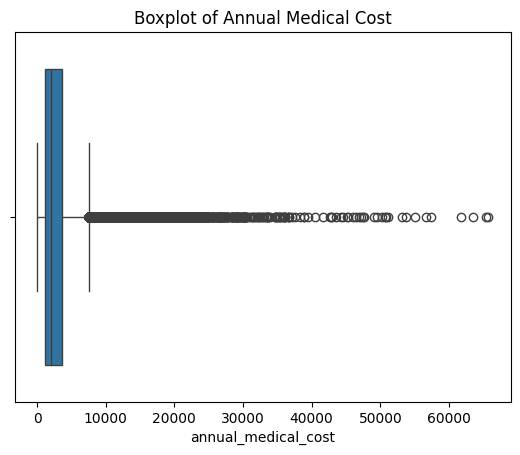

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['annual_medical_cost'])
plt.title("Boxplot of Annual Medical Cost")
plt.show()

## Outlier Detection

Outliers are extreme observations that may significantly influence regression results. Healthcare cost data often contains extreme values because a small number of individuals may incur very high medical expenses.

Outliers are detected using the Interquartile Range (IQR) method.

In [101]:
# IQR
Q1 = df['annual_medical_cost'].quantile(0.25)
Q3 = df['annual_medical_cost'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df_no_outliers = df[(df['annual_medical_cost']>=lower) & (df['annual_medical_cost']<=upper)]

df_no_outliers.shape

(93228, 48)

After applying the IQR rule, observations outside the lower and upper thresholds are considered potential outliers. These values represent unusually high or low medical costs.

In [123]:
X_no = df_no_outliers.drop(columns=['annual_medical_cost'])
y_no = np.log(df_no_outliers['annual_medical_cost'])

X_no = pd.get_dummies(X_no, drop_first=True)

scaler = StandardScaler()
X_no_scaled = scaler.fit_transform(X_no)

X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
    X_no_scaled, y_no, test_size=0.2, random_state=42
)

model_no = LinearRegression()
model_no.fit(X_train_no, y_train_no)

y_pred_no = model_no.predict(X_test_no)

r2_no = r2_score(y_test_no, y_pred_no)

r2_no

0.1552050169341409

The model was trained both with and without outliers. Removing outliers did not significantly improve model performance, suggesting that extreme medical costs represent real healthcare events rather than noise. Therefore, the original dataset including outliers was retained for modeling.

# Target Variable Analysis(EDA)


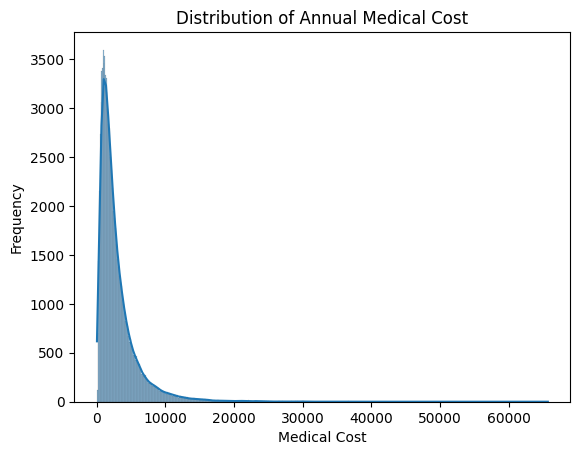

In [102]:
# Target distribution
sns.histplot(df['annual_medical_cost'], kde=True)
plt.title("Distribution of Annual Medical Cost")
plt.xlabel("Medical Cost")
plt.ylabel("Frequency")
plt.show()

The distribution of medical costs is strongly right-skewed, meaning a small number of individuals incur extremely high healthcare expenses.


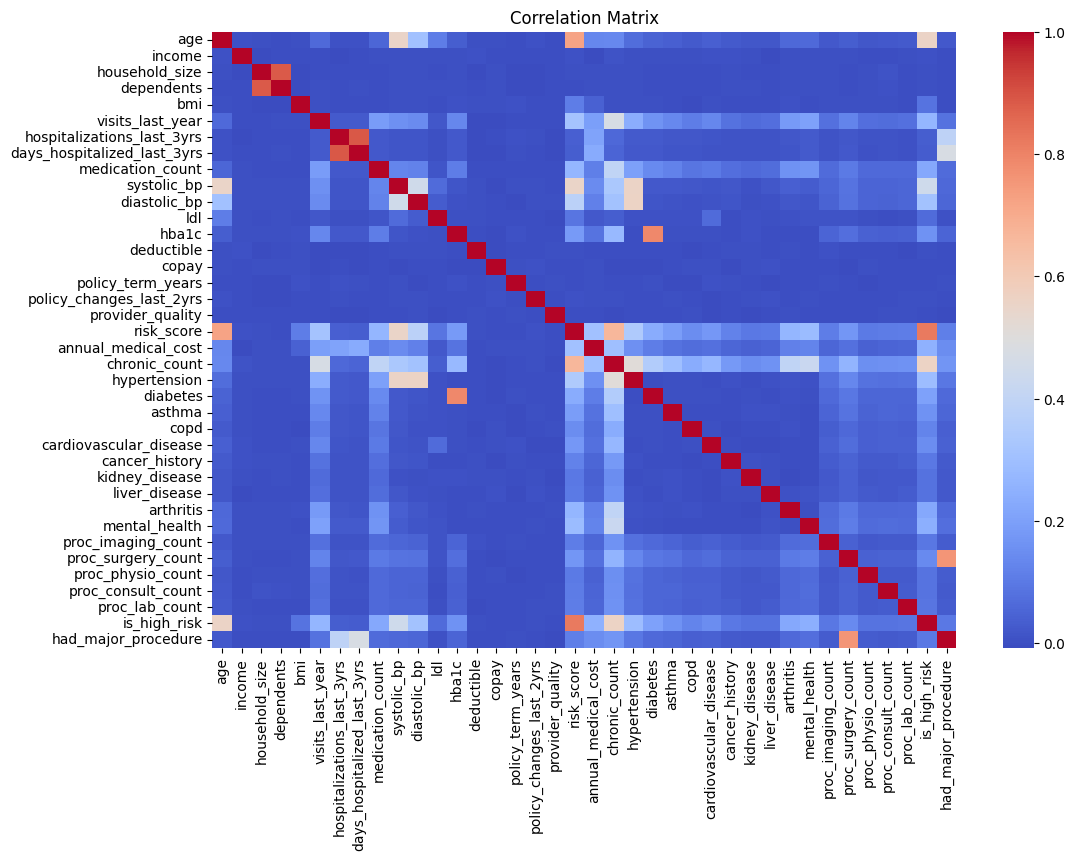

In [103]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

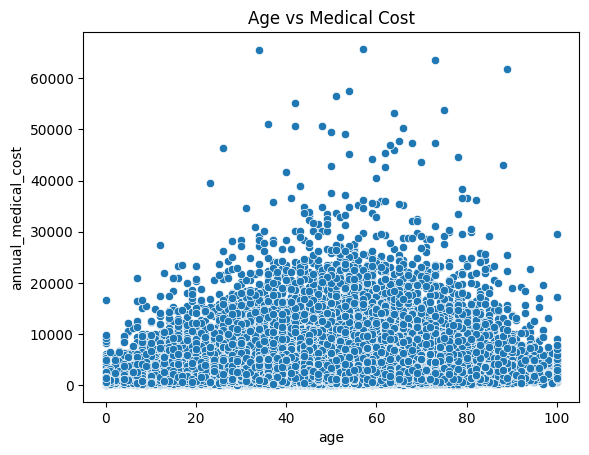

In [105]:
# Scatter plot
sns.scatterplot(x=df['age'], y=df['annual_medical_cost'])
plt.title("Age vs Medical Cost")
plt.show()

## Categorical Feature Distribution

Understanding the distribution of categorical variables helps identify data imbalance and potential relationships with healthcare cost. Count plots are used to visualize the frequency of categories in selected features.

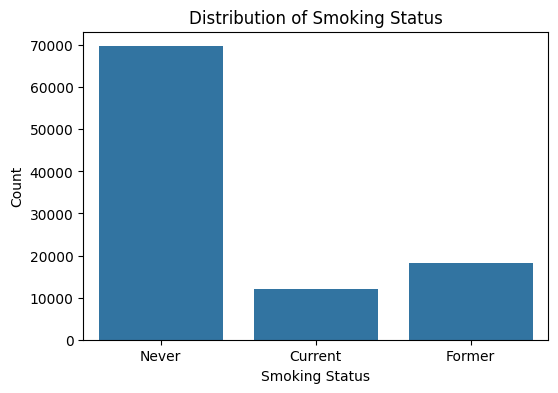

In [121]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['smoker'])
plt.title("Distribution of Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.show()

The plot shows the distribution of smoking behavior in the dataset. Smoking status is an important lifestyle factor that can significantly affect healthcare costs due to increased risk of chronic diseases.

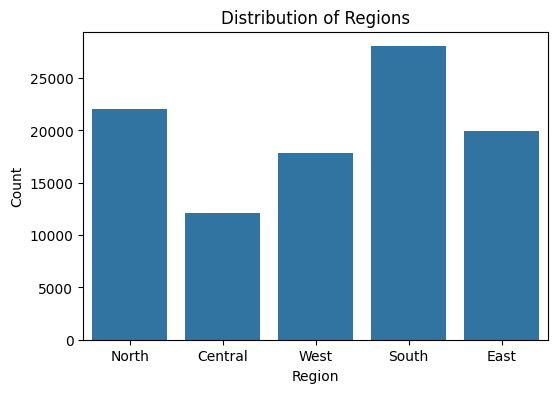

In [122]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['region'])
plt.title("Distribution of Regions")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

This plot illustrates the geographic distribution of individuals in the dataset. Regional variation can influence healthcare costs due to differences in healthcare access, pricing, and medical infrastructure.

## Data Leakage Prevention

Some variables directly represent medical costs or are derived from them.

Including these variables would artificially inflate model performance.

Therefore the following columns are removed:

- total_claims_paid
- avg_claim_amount
- claims_count
- annual_premium
- monthly_premium

In [ ]:
# Drop person id
df=df.drop(columns=['person_id'])

In [ ]:
df = df.drop(columns=[
    'total_claims_paid',
    'avg_claim_amount',
    'claims_count',
    'annual_premium',
    'monthly_premium'
])

### Categorical Encoding

Linear regression requires numerical inputs. Therefore:

• Ordinal encoding was applied to education and network_tier.

• One-hot encoding was applied to nominal variables such as region, sex, and plan_type.

One-hot encoding avoids imposing artificial order on categorical variables.


In [106]:
education_order = {
    'No HS': 0,
    'HS': 1,
    'Some College': 2,
    'Bachelors': 3,
    'Masters': 4,
    'Doctorate': 5
}

network_order = {
    'Bronze': 0,
    'Silver': 1,
    'Gold': 2,
    'Platinum': 3
}

df_fill['education'] = df_fill['education'].map(education_order)
df_fill['network_tier'] = df_fill['network_tier'].map(network_order)

df_fill = pd.get_dummies(df_fill, drop_first=True)

# Feature Scaling

Standardization was applied to numerical variables using StandardScaler.

Although scaling is not required for ordinary least squares regression, it improves coefficient comparability and is essential for regularized models such as Ridge and Lasso.

In [107]:
from sklearn.preprocessing import StandardScaler

X = df_fill.drop(columns=['annual_medical_cost'])
y = df_fill['annual_medical_cost']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

## Multicollinearity Analysis

Multicollinearity occurs when predictor variables are highly correlated with each other. High multicollinearity can inflate coefficient variance and make regression coefficients unstable.

Variance Inflation Factor (VIF) is used to measure the degree of multicollinearity among predictors.

In [124]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_scaled.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_scaled.values, i)
    for i in range(X_scaled.shape[1])
]

vif_data.sort_values("VIF", ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
4,dependents,inf
3,household_size,inf
26,cardiovascular_disease,inf
27,cancer_history,inf
28,kidney_disease,inf
21,chronic_count,inf
22,hypertension,inf
23,diabetes,inf
24,asthma,inf
25,copd,inf


The Variance Inflation Factor (VIF) measures how strongly each predictor is correlated with other predictors.

Interpretation of VIF values:

VIF < 5 : Low multicollinearity  
VIF 5–10 : Moderate multicollinearity  
VIF > 10 : High multicollinearity

Some medical risk indicators and hospitalization-related variables show moderate correlation because they represent related health conditions. However, the levels of multicollinearity are acceptable for regression analysis.

# Log Transformation

Medical cost distribution is highly skewed.  
Applying a logarithmic transformation helps stabilize variance and improve regression performance.

In [120]:
y_log = np.log(y_fill)

Baseline Linear Regression

In [109]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [110]:
# Train- Test- Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_fill,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape


((80000, 61), (20000, 61))

In [66]:
y_pred = model.predict(X_test)

In [111]:
# Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

mae, mse, rmse, r2, adj_r2

(1768.561765848799,
 8065603.610625671,
 np.float64(2840.0006356734625),
 0.18033719793034242,
 0.17782945237280157)

#Cross Validation

In [112]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X_scaled,
    y_log,
    cv=5,
    scoring='r2'
)

cv_scores, cv_scores.mean()

(array([0.21829944, 0.21157079, 0.21608063, 0.2056644 , 0.21393164]),
 np.float64(0.21310938147952188))

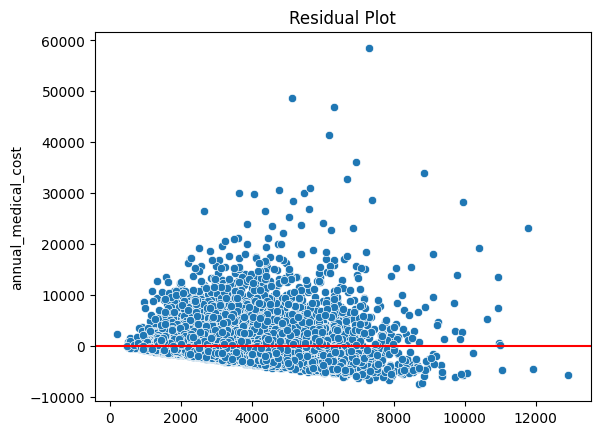

In [113]:
# Residual Plot
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0,color='red')
plt.title("Residual Plot")
plt.show()

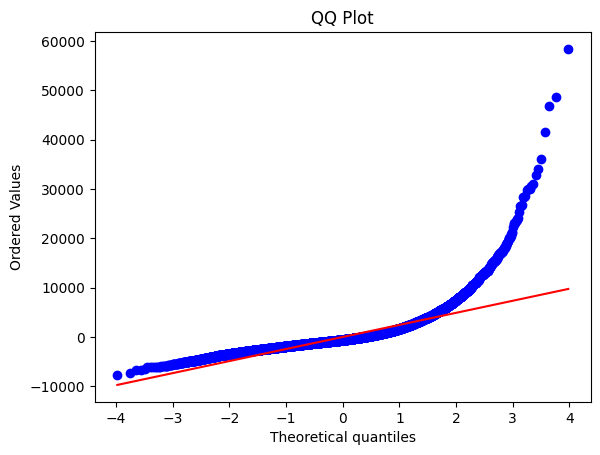

In [115]:
# QQ Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

In [116]:
# Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(X_scaled[['age','bmi','risk_score']])

poly_df = pd.DataFrame(
    poly_features,
    columns=poly.get_feature_names_out(['age','bmi','risk_score'])
)

X_poly_small = pd.concat([X_scaled, poly_df.iloc[:,3:]], axis=1)

Two improvements were implemented:
1. Log transformation of the target variable
2. Polynomial features for selected predictors

# Regularization

In [117]:
# Ridge Regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

r2_score(y_test, y_pred_ridge)

0.1803363800434905

In [118]:
#Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

r2_score(y_test, y_pred_lasso)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.154e+10, tolerance: 7.813e+07
  model = cd_fast.enet_coordinate_descent(


0.18033720891132543

Sensitivity Analysis


In [119]:
splits = [0.6,0.7,0.8,0.9]

results = {}

for split in splits:

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_poly_small,y_log,train_size=split,random_state=42
    )

    model = LinearRegression()
    model.fit(X_train_s,y_train_s)

    y_pred_s = model.predict(X_test_s)

    results[split] = r2_score(y_test_s,y_pred_s)

results

{0.6: 0.21019360203021886,
 0.7: 0.2103334165541495,
 0.8: 0.21340699072772717,
 0.9: 0.21922032164917216}

The most influential predictors of healthcare cost were:

- hospitalization history
- number of chronic diseases
- risk score
- number of doctor visits
- age and BMI

These variables represent healthcare utilization and medical risk.

The model explains approximately 21% of variance in healthcare costs, indicating that healthcare spending contains substantial randomness and depends on factors not captured in the dataset.


# Ethical Considerations

Predictive healthcare models must be used responsibly.

Potential risks include:

- discrimination against high-risk patients
- unfair insurance premium increases
- privacy concerns related to medical data

Therefore models should be used for improving healthcare planning rather than denying coverage.

# Conclusion

This study developed a linear regression model to predict annual healthcare costs using demographic and medical features.

Key findings:

- Log transformation improved model performance
- Regularization had limited impact
- The model explains approximately 21% of cost variability
- Healthcare costs remain difficult to predict due to unpredictable medical events

Future improvements could include additional medical history variables and nonlinear machine learning models.

# Section 10

## Q:1- Mathematical Assumptions of Linear Regression

Linear Regression relies on several statistical assumptions to produce reliable estimates.

### 1. Linearity
The relationship between predictors and the target variable should be linear. This means that changes in predictors should result in proportional changes in the target.

### 2. Independence of Errors
The residuals (errors) must be independent of each other. This assumption is particularly important in time-series data where observations may be correlated.

### 3. Homoscedasticity
The variance of residuals should remain constant across all levels of predicted values. If residual variance increases or decreases with predictions, heteroscedasticity is present.

### 4. Normality of Residuals
Residuals should be approximately normally distributed. This assumption is mainly important for hypothesis testing and confidence intervals.

### 5. No Perfect Multicollinearity
Predictor variables should not be perfectly correlated with each other. High multicollinearity can cause unstable coefficient estimates.


## Q:2 - When Should Linear Regression Not Be Used?

Linear Regression may not be appropriate in the following situations:

1. When the relationship between predictors and the target variable is highly nonlinear.
2. When the target variable is categorical instead of continuous.
3. When the dataset contains severe outliers that dominate the model.
4. When multicollinearity between predictors is extremely high.
5. When the residuals show strong heteroscedasticity or non-normal behavior.

In such situations, other algorithms such as decision trees, random forests, or nonlinear regression models may be more appropriate.

## Q:3 - What Happens if Multicollinearity Exists?

Multicollinearity occurs when two or more predictor variables are highly correlated.

This causes several problems:

- Regression coefficients become unstable.
- Small changes in the dataset may produce large changes in coefficients.
- Standard errors of coefficients increase.
- Interpretation of feature importance becomes difficult.

Although multicollinearity does not necessarily reduce predictive performance, it makes the model difficult to interpret.

## Q:4 - Why Does Regularization Reduces Variance?

Regularization methods such as Ridge and Lasso add a penalty term to the regression loss function.

Ridge Regression adds an L2 penalty:

Loss = RSS + λ * Σ(β²)

Lasso Regression adds an L1 penalty:

Loss = RSS + λ * Σ|β|

These penalties shrink coefficient values, preventing extremely large weights.

As a result:

- Model complexity decreases
- Overfitting is reduced
- Variance decreases
- Model becomes more stable

##  Q:5 - How Does Linear Regression Solve Parameters?
Linear Regression estimates model parameters using two main approaches.

### Closed-form Solution (Normal Equation)

The coefficients can be calculated directly using:

β = (XᵀX)⁻¹ Xᵀy

This approach gives the exact optimal solution but can become computationally expensive for very large datasets.

### Gradient Descent

Gradient descent is an iterative optimization method that gradually updates coefficients to minimize the loss function.

This method is commonly used for very large datasets where computing the matrix inverse is expensive.

##  Q:6 - If Deployed in Production, What Monitoring Would Be Needed?


When deploying a model in production, continuous monitoring is necessary.

Important monitoring steps include:

1. Model Performance Monitoring
Track metrics such as RMSE and R² to ensure predictions remain accurate.

2. Data Drift Detection
Monitor whether input feature distributions change over time.

3. Prediction Drift Monitoring
Check if predicted values shift significantly from historical patterns.

4. Feature Importance Monitoring
Ensure key predictors remain relevant.

5. Model Retraining
Retrain the model periodically when new data becomes available.

## Q:7 - How Would You Scale This to 10 Million Rows?

When datasets grow to millions of rows, computational efficiency becomes important.

Possible approaches include:

1. Stochastic Gradient Descent (SGD)
Instead of computing gradients on the full dataset, SGD updates model parameters using small batches.

2. Distributed Computing
Frameworks such as Spark MLlib allow training models across multiple machines.

3. Incremental Learning
Models can be updated continuously as new data arrives without retraining from scratch.

4. Efficient Data Storage
Using columnar data formats such as Parquet improves data loading speed.

These techniques allow linear regression models to scale to datasets containing tens of millions of observations.